In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Heart_Disease_Prediction.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [4]:
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


Выбран набор данных для прогнозирования сердечных заболеваний. Пропусков нет.

## Определение типов переменных

In [5]:
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

### Числовые

Имеют порядок, над ними имеют смысл математические операции

- Age (Возраст в годах) - int64

- BP (Артериальное давление в состоянии покоя, мм рт.ст.) - int64

- Cholesterol (Холестерин в мг/дл) - int64

- Max HR (Максимальная достигнутая частота сердечных сокращений) - int64

- ST depression (Депрессия сегмента ST, вызванная физической нагрузкой) - float64

### Порядковые (Ordinal)

Имеют естественный порядок, но интервалы между значениями не равны или не имеют строгого математического смысла

- Chest pain type (Тип боли в груди) - int64

Значения: 1-4 (обычно: 1=типичная стенокардия, 2=атипичная стенокардия, 3=неангинальная боль, 4=бессимптомно)

- Slope of ST (Наклон пикового сегмента ST при нагрузке) - int64

Значения: 1-3 (1=восходящий, 2=плоский, 3=нисходящий) - явный порядок!

- Thallium (Результат теста с таллием) - int64

Значения: 3, 6, 7 (обычно: 3=нормальный, 6=фиксированный дефект, 7=обратимый дефект) - есть порядок тяжести!

### Категориальные/Бинарные (Categorical/Binary)

Нет естественного порядка

- Sex (Пол) - int64

Значения: 1=мужской, 0=женский

- FBS over 120 (Уровень сахара натощак > 120 мг/дл) - int64

Значения: 1=да, 0=нет - бинарная

- EKG results (Результаты ЭКГ в покое) - int64

Значения: 0-2 (обычно: 0=норма, 1=аномалия ST-T, 2=гипертрофия левого желудочка)

Спорный момент: Можно считать порядковой (по степени отклонения от нормы) или номинальной. Для простоты можно считать категориальной.

- Exercise angina (Стенокардия, вызванная физической нагрузкой) - int64

Значения: 1=да, 0=нет - бинарная

- Number of vessels fluro (Количество основных сосудов, окрашенных при флюороскопии) - int64

Значения: 0-3

## Визуализация распределения переменных

Гистограмма для числовых переменных

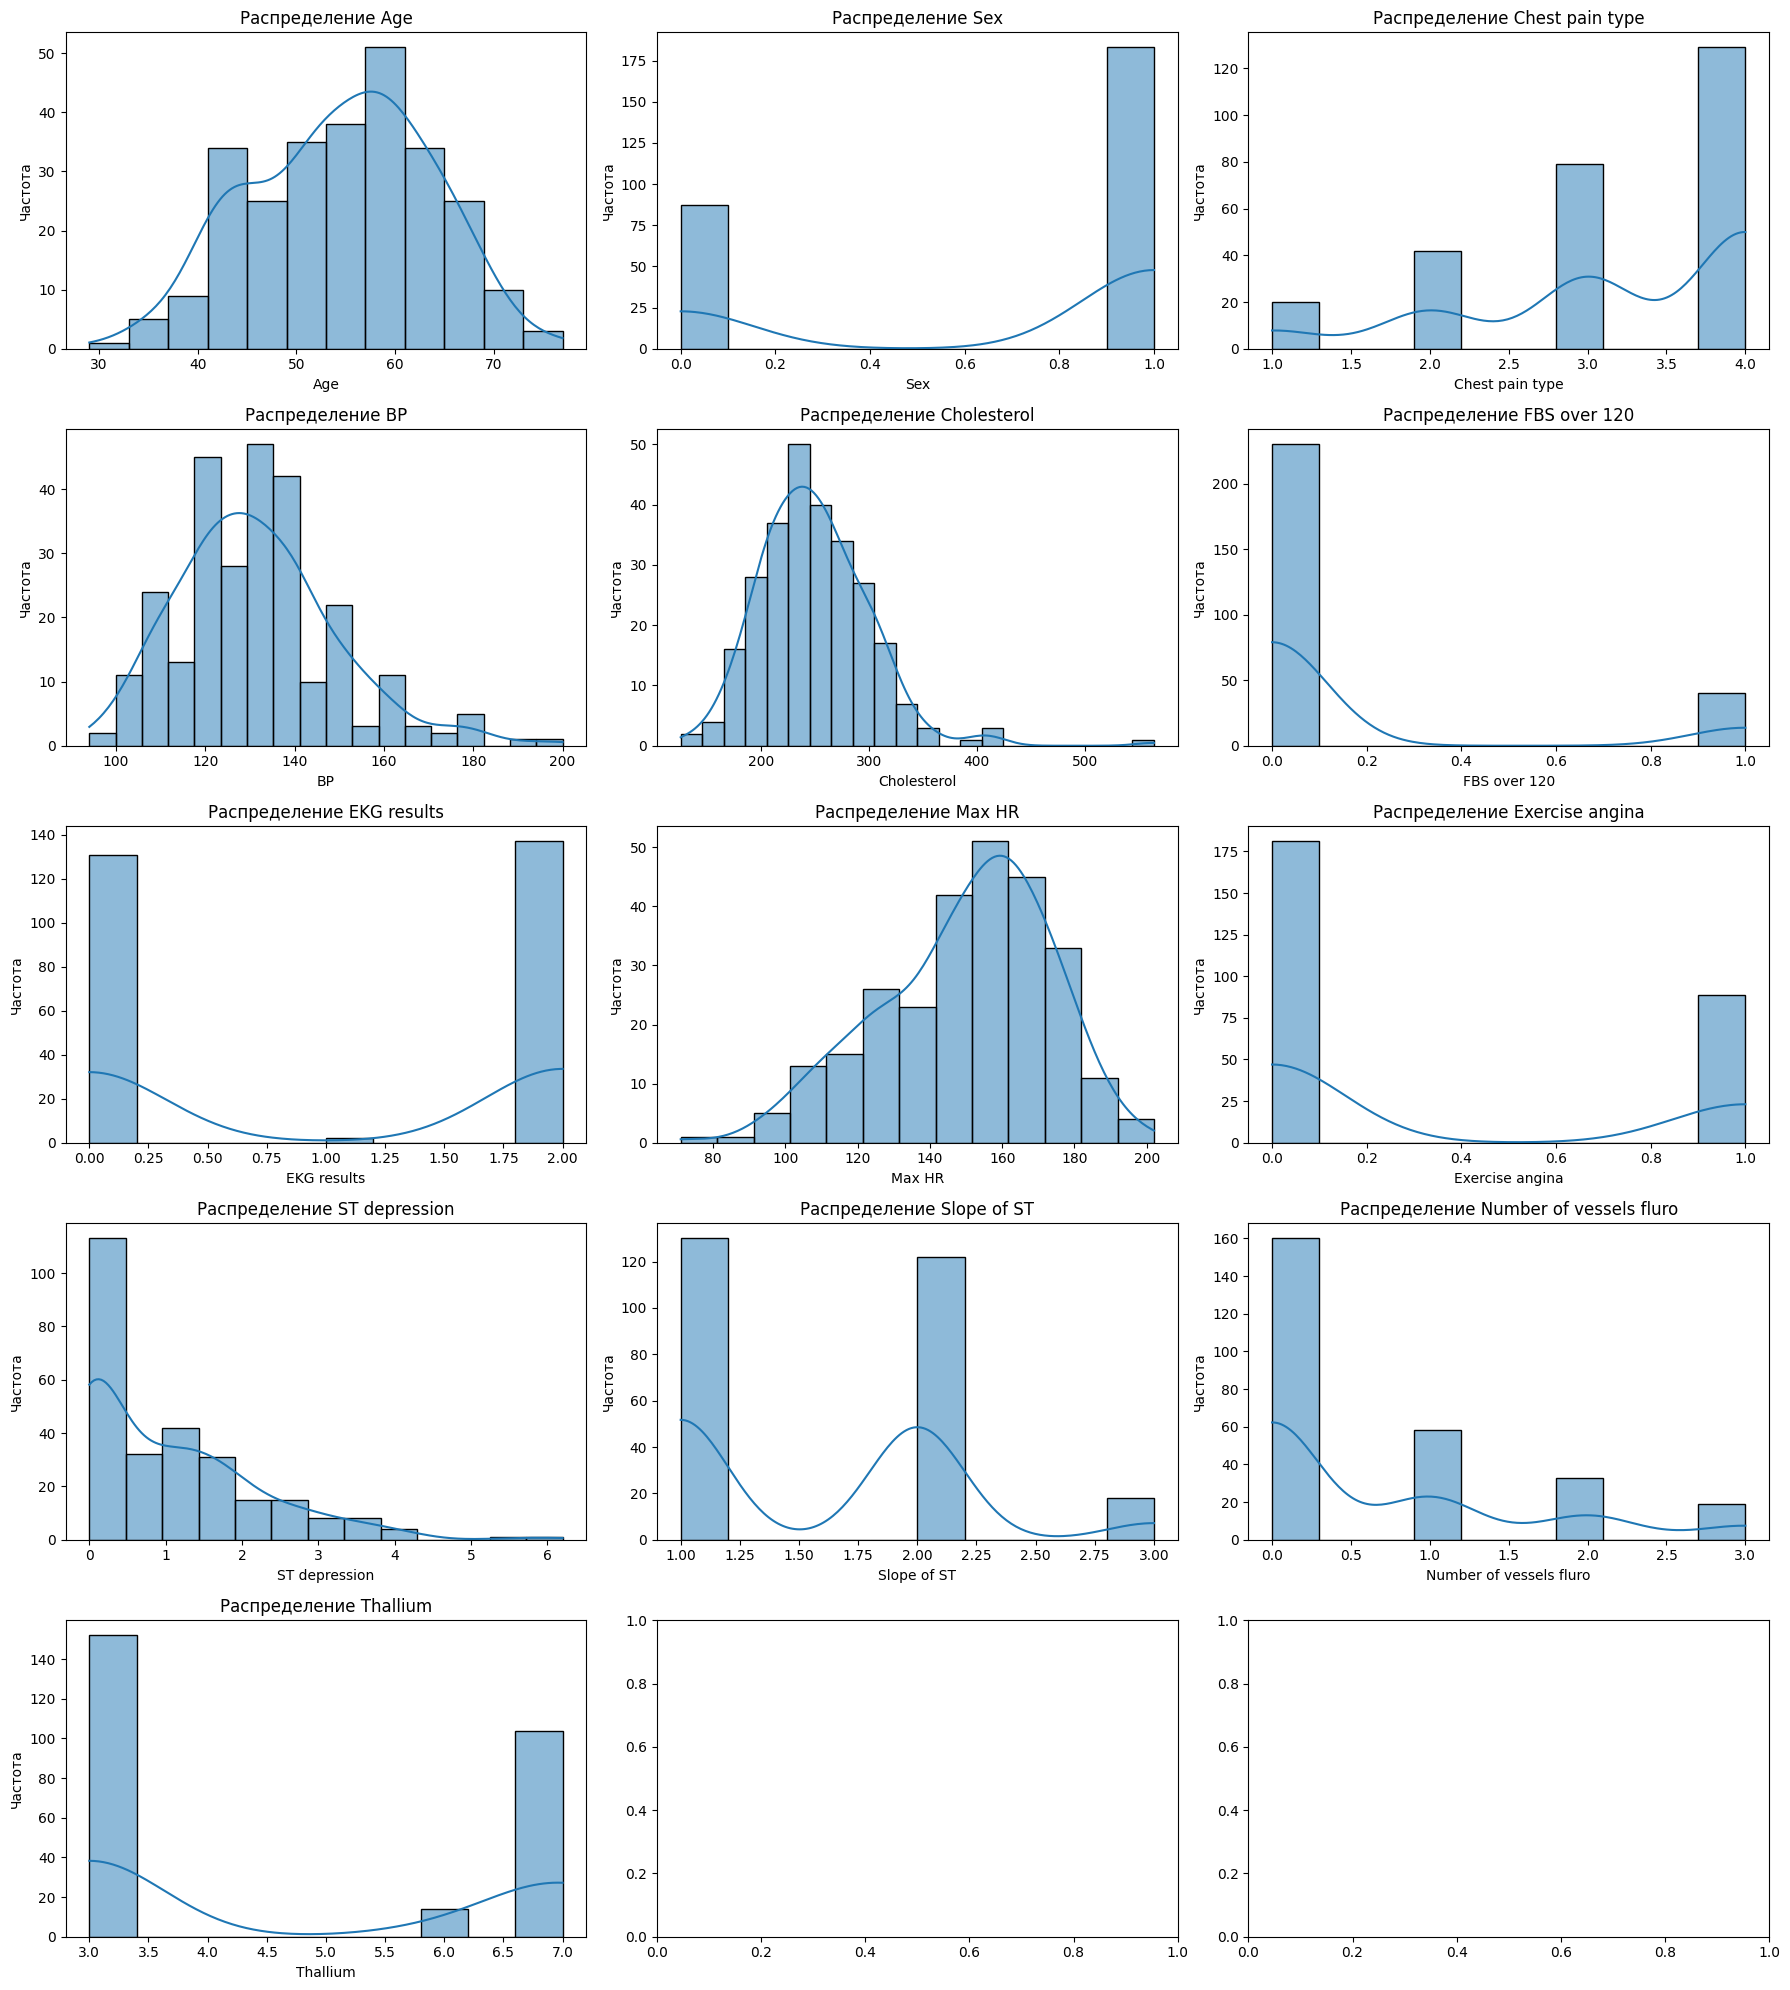

In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(num_cols)
n_rows = (n_cols + 2) // 3 
    
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten()
    
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    
plt.tight_layout()
plt.show()





#### Age (Возраст)
- Основной возрастной сегмент от 42 до 65
- Больше всего наблюдейний у людей возрастом 60 лет (классический возраст для проявления ишемической болезни сердца)

#### Sex (Пол)
- Мужчин в 2 раза больше, чем женщин

#### Chest pain type (Тип боли в груди)
- Более растространенный тип боли в груди бессимптомный и нестенокардический, то есть боль чаще всего не связана с сердцем

#### BP (Артериальное давление)
- Распределение близко к нормальному с небольшим смешением влево
- Систолическое давление чаще всего в пределах нормы (120-140), но на него нужно смотреть исходя из возраста и пола пациента
- Есть также критически низкие (100) и высокие (160-200) отметки, возможно связанные с заболеванием

#### Cholesterol (Холестерин)
- Большая часть показателей от 200 до 300 (очень высокие показатели)
- Есть значения выше 300 (большой риск)

#### FBS over 120 (Уровень сахара натощак)
- У большей части менее 120 мг\Дл сахара в крови

#### EKG results (Результаты ЭКГ)
- 0 = норма, 1 = аномалия ST-T (может быть ишемия), 2 = гипертрофия ЛЖ (увеличение сердца)
- Равное распределение между 0 и 2 говорит о том, что у многих уже есть структурные изменения сердца

#### Max HR (Макс ЧСС)
- Масимальная ЧСС 140-180 ударов

#### Exercise angina (Стенокардия)
- Физическая нагрузка вызыввает стенокардию у 2/3 опрашиваемых

#### ST depression (Депрессия сегмента ST)
- больше 0.1 mV (1 мм) считается патологическим при нагрузке
- Пик на 0 — у многих тест отрицательный
- Но есть "хвост" до 4.2 — это явная ишемия у части пациентов

#### Slope of ST (Наклон пикового сегмента ST при нагрузке)
- Наклон пика ст принимет значения 1 или 2, что в пределах нормы

#### Number of vessels fluro (Количество основных сосудов, окрашенных при флюороскопии)
- Больше всего наблюдений на 0, то есть нет критических закупорок артерий
- от 1 до 3 постепенно уменьшается частота записей

#### Thallium (Результат теста с таллием)
- 3 = нормальное кровоснабжение, 6 = фиксированный дефект (рубец после инфаркта), 7 = обратимый дефект (ишемия — недостаток кровоснабжения при нагрузке)
- У большинства норма (3), но значительная часть имеет обратимые дефекты (7) — ишемию миокарда

## Столбчатая диаграмма для категориальной переменной 


Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


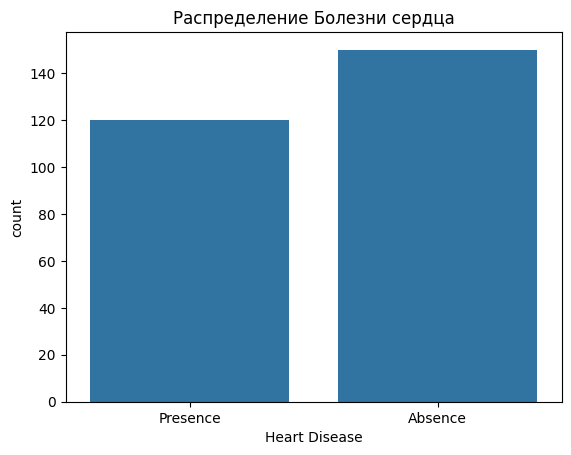

In [9]:
print(df["Heart Disease"].value_counts())
sns.countplot(data=df, x="Heart Disease")
plt.title("Распределение Болезни сердца")
plt.show()

- Presence = выявлено заболевание сердца
- Absence = заболевания сердца нет
- Здоровых людей на 20% больше

## Боксплот для числовой переменной


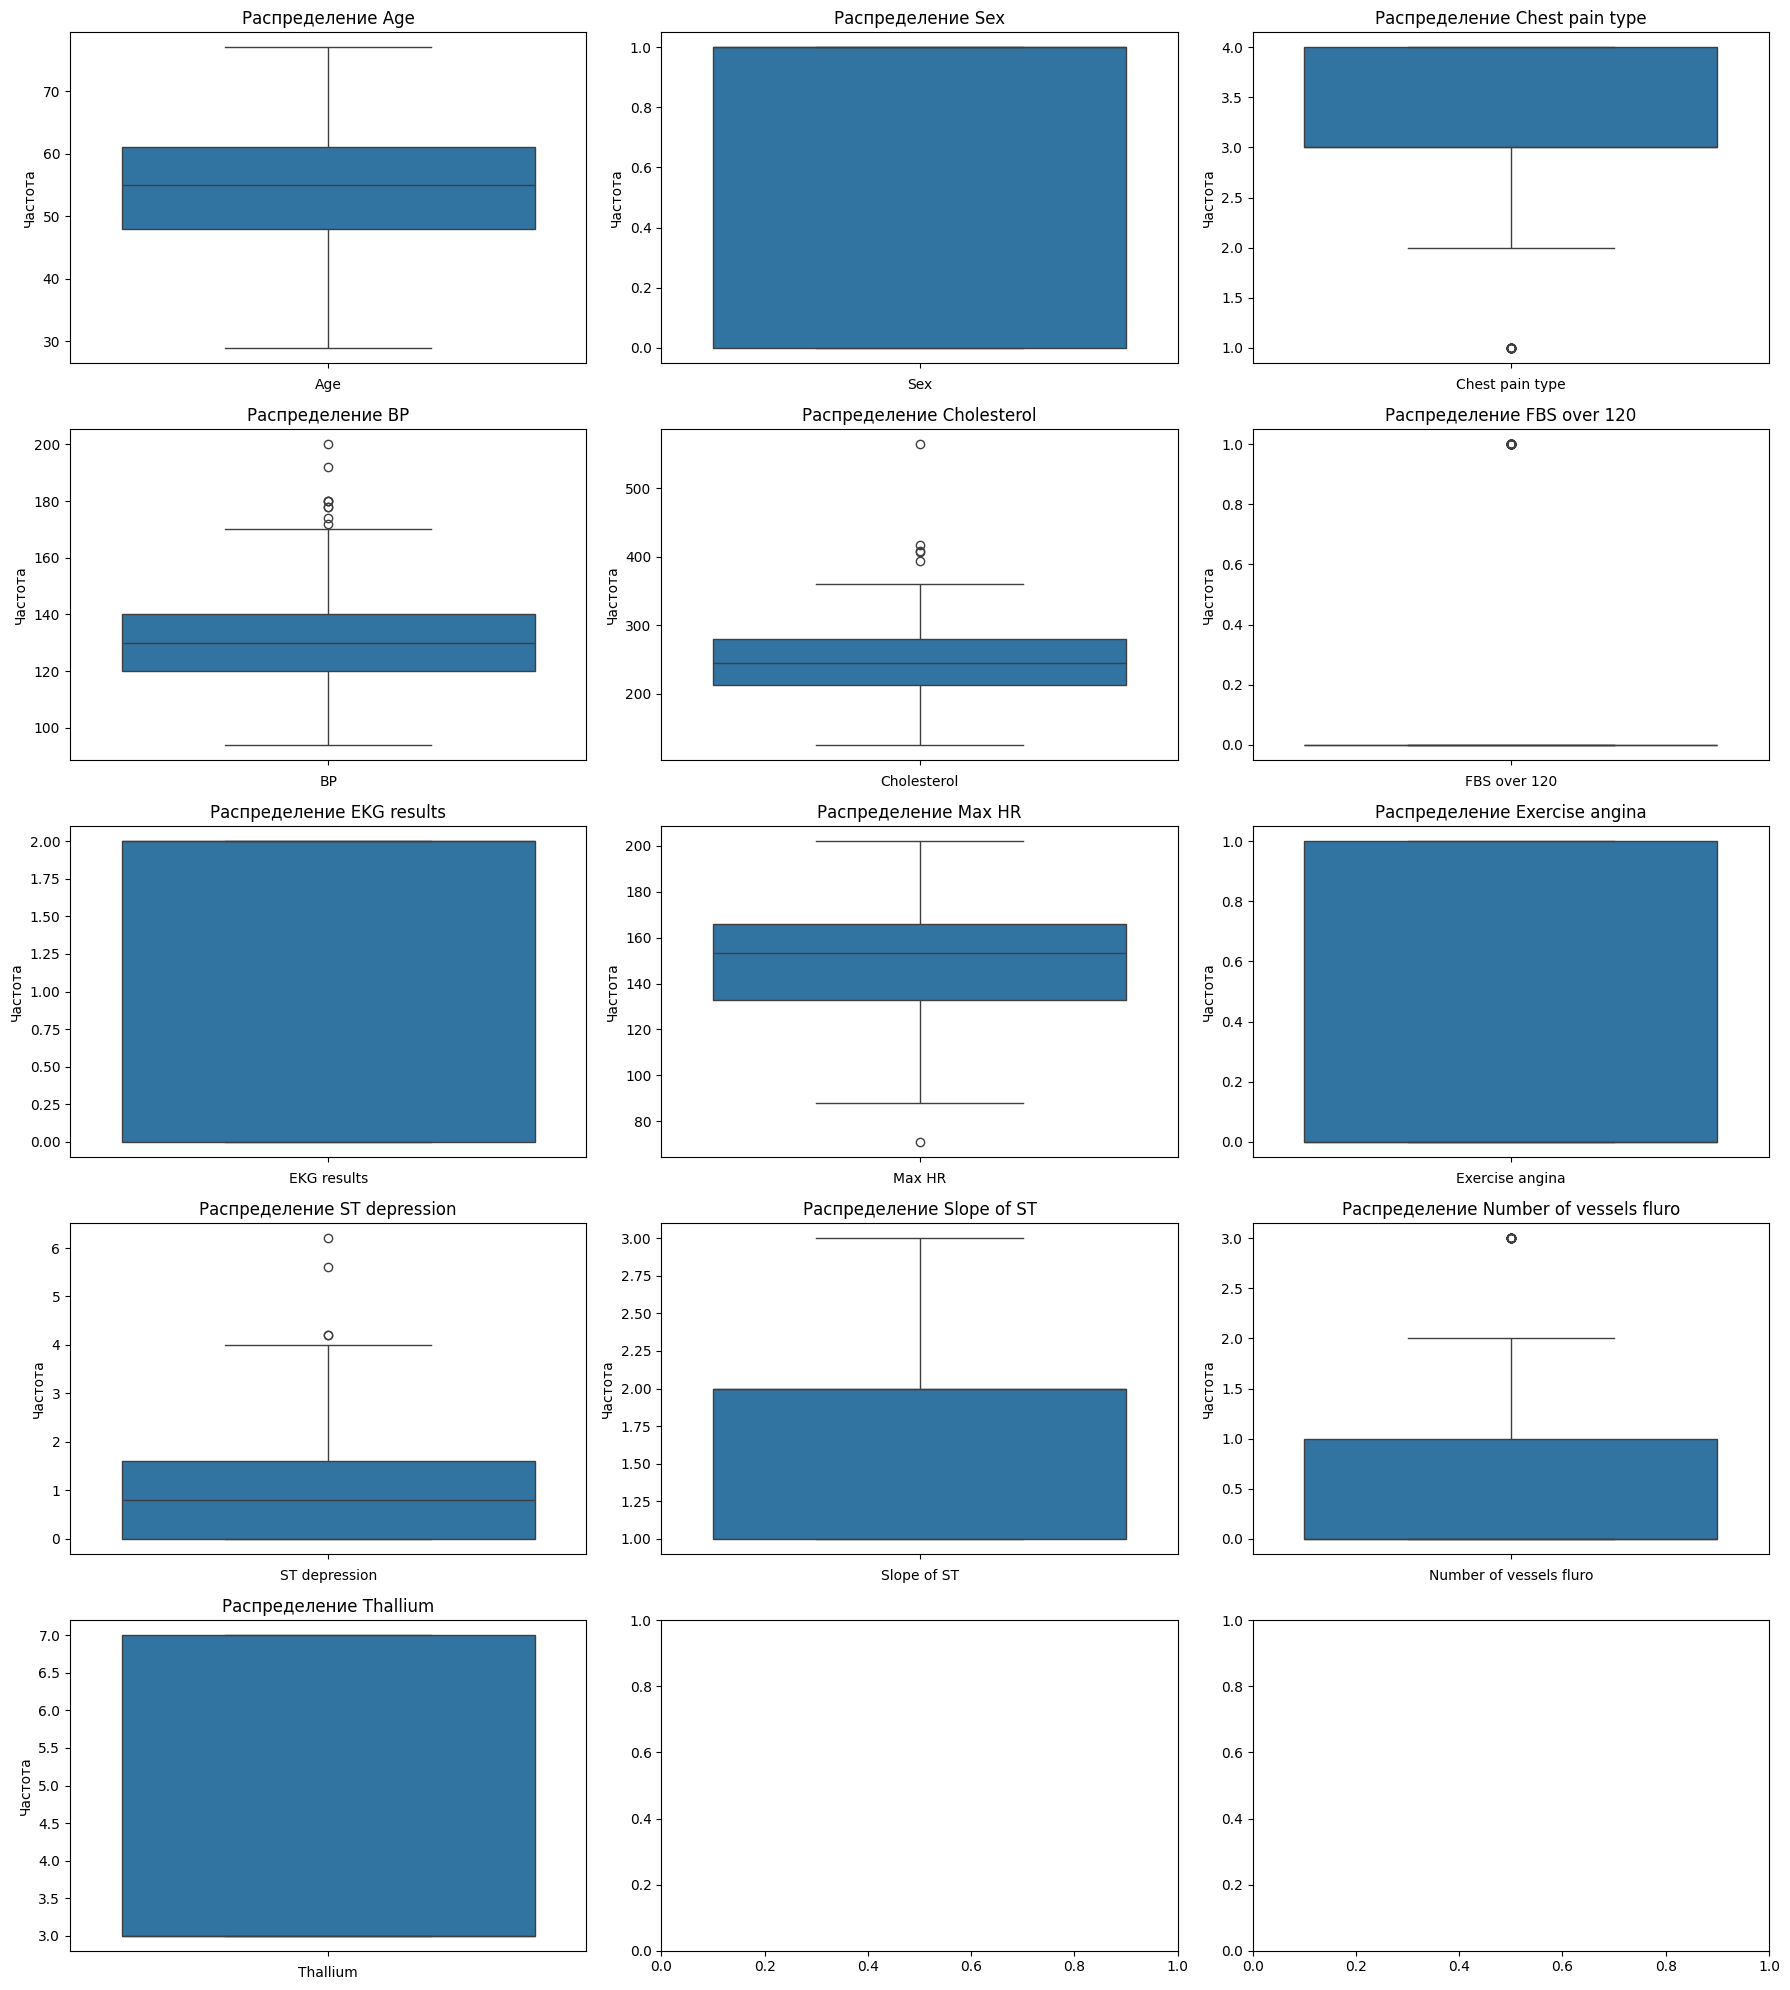

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(num_cols)
n_rows = (n_cols + 2) // 3 
    
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
   sns.boxplot(df[col], ax=ax)
   ax.set_title(f'Распределение {col}')
   ax.set_xlabel(col)
   ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

Выбросы присутствуют на распределении: Артериального давления, Холестирина, Типа боли в груди, Депресии СТ, Маскимальном ЧСС, Количестве окрашенных сосудов. 

- Экстремально высокий холестерин (>400) указывает на возможную генетическую патологию

- Глубокая депрессия ST (>2мм) — маркер тяжелой ишемии миокарда

- Аномально низкая ЧСС при нагрузке — признак нарушения проводящей системы сердца

## Корреляционная матрица

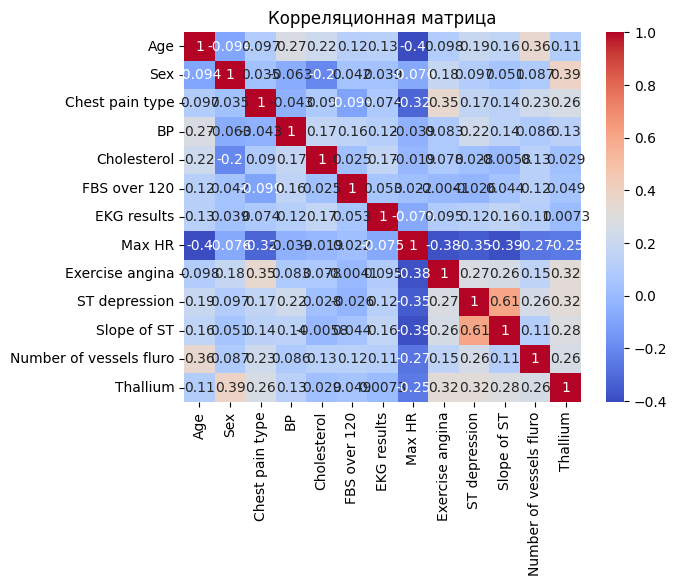

In [11]:
# Корреляционная матрица
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# Визуализация тепловой карты
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

### Положительная корреляция

- Депрессия Ст и Наклон пика ST-сегмента при физической нагрузке

Чем больше депрессия ST (недостаток кровоснабжения), тем более патологический наклон ST

### Умеренная положительная корреляция

- Пол и Тест на таллиум

Мужчины чаще имеют положительные нагрузочные тесты

- Количество крупных сосудов и возраст

Чем старше пациент, тем больше пораженных коронарных сосудов

- Тип боли и стенокардия

Если боль сердечная, она провоцируется физической активностью

### Отрицательная корреляция

- ЧСС и возраст\тип боли\стенокардия\депрессия ст\наклон пика ст
С возрастом — физиологическое снижение максимальной ЧСС

При ишемии — сердце не может увеличить ЧСС из-за недостатка кровоснабжения

При стенокардии — боль ограничивает нагрузку

Вывод: Низкая максимальная ЧСС — маркер сердечной патологии

- Холестирин и пол

### Слабая отрицательная корреляция

- Возраст и тест на таллиум

С возрастом реже нормальные результаты теста

- Давление и возраст\тип боли\ЧСС

## Object -> category

In [12]:
df['Heart Disease'] = df['Heart Disease'].astype('category')

## Выбор признаков

In [19]:
# Y - переменная, которую мы хотим исследовать, предсказать, и так далее
# X - зависимые перменные, влияние которых мы изучаем на Y
y = df['Heart Disease']
X = df.drop('Heart Disease', axis=1) if 'Heart Disease' in df.columns else df

X.head(n=3)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7


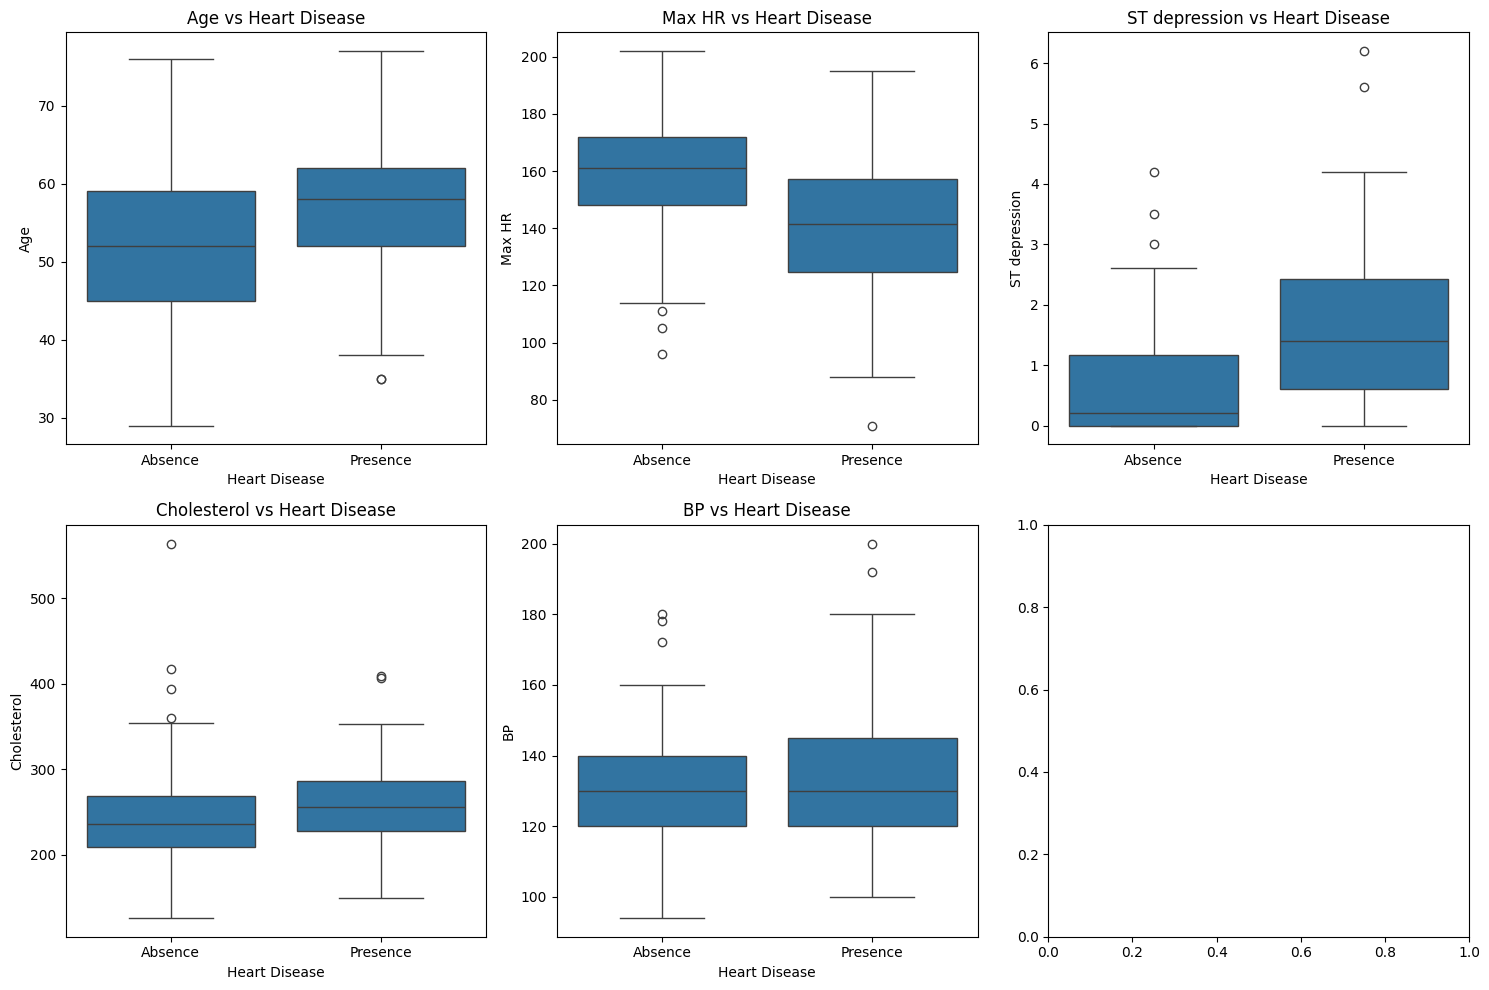

In [33]:
# Графики для числовых признаков
numeric_features = ['Age', 'Max HR', 'ST depression', 'Cholesterol', 'BP']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(numeric_features):
    row = i // 3
    col = i % 3
    sns.boxplot(x='Heart Disease', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} vs Heart Disease')

plt.tight_layout()
plt.show()

In [29]:
print("=== АНАЛИЗ BOXPLOT: РАЗНИЦА МЕДИАН ===")
for feature in ['Age', 'Max HR', 'ST depression', 'Cholesterol', 'BP']:
    medians = df.groupby('Heart Disease')[feature].median()
    diff = medians['Absence'] - medians['Presence']
    
    print(f"\n{feature}:")
    print(f"  Медиана Presence: {medians['Presence']:.1f}")
    print(f"  Медиана Absence: {medians['Absence']:.1f}")
    print(f"  Разница медиан: {diff:.1f}")
    
    # Относительная разница
    rel_diff = diff / medians.mean() * 100
    print(f"  Относительная разница: {rel_diff:.1f}%")
    
    # Интерпретация
    if abs(rel_diff) > 20:
        strength = "СИЛЬНАЯ"
    elif abs(rel_diff) > 10:
        strength = "УМЕРЕННАЯ"
    else:
        strength = "СЛАБАЯ"
    print(f"  {strength} разница между группами")

=== АНАЛИЗ BOXPLOT: РАЗНИЦА МЕДИАН ===

Age:
  Медиана Presence: 58.0
  Медиана Absence: 52.0
  Разница медиан: -6.0
  Относительная разница: -10.9%
  УМЕРЕННАЯ разница между группами

Max HR:
  Медиана Presence: 141.5
  Медиана Absence: 161.0
  Разница медиан: 19.5
  Относительная разница: 12.9%
  УМЕРЕННАЯ разница между группами

ST depression:
  Медиана Presence: 1.4
  Медиана Absence: 0.2
  Разница медиан: -1.2
  Относительная разница: -150.0%
  СИЛЬНАЯ разница между группами

Cholesterol:
  Медиана Presence: 255.5
  Медиана Absence: 236.0
  Разница медиан: -19.5
  Относительная разница: -7.9%
  СЛАБАЯ разница между группами

BP:
  Медиана Presence: 130.0
  Медиана Absence: 130.0
  Разница медиан: 0.0
  Относительная разница: 0.0%
  СЛАБАЯ разница между группами


C:\Users\margo\AppData\Local\Temp\ipykernel_10840\3822448.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = df.groupby('Heart Disease')[feature].median()


### ST depression (-150% разница!)

Депрессия ST > 1.0 мм — диагностический критерий ишемии. У больных значения в 7 раз выше — это очень сильный маркер.

### Max HR (12.9% разница)

Пациенты с ИБС не могут достичь высокой ЧСС из-за ограниченного коронарного резерва. Разница 20 уд/мин клинически значима.

### Age (-10.9% разница)

Возраст — известный фактор риска. Больные в среднем на 6 лет старше.

### Cholesterol (-7.9%) и BP (0%)

Холестерин: разница 19.5 мг/дл (граница нормы/патологии)

Давление: никакой разницы — неожиданно, но объяснимо

<Figure size 800x400 with 0 Axes>

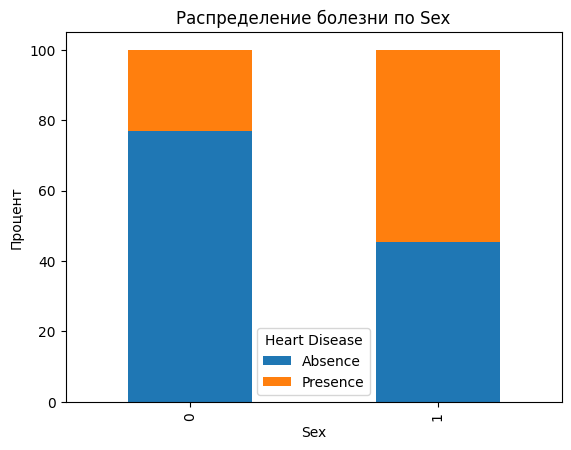

<Figure size 800x400 with 0 Axes>

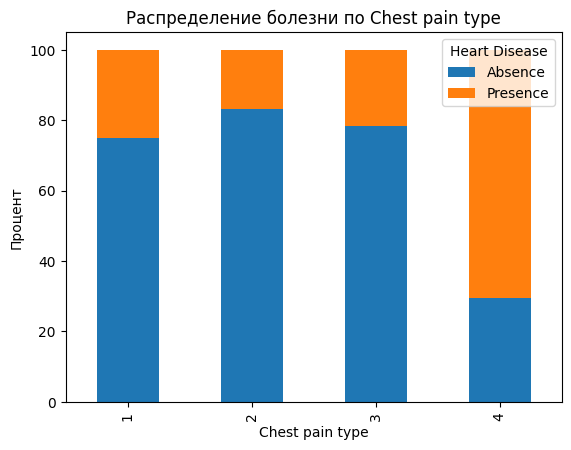

<Figure size 800x400 with 0 Axes>

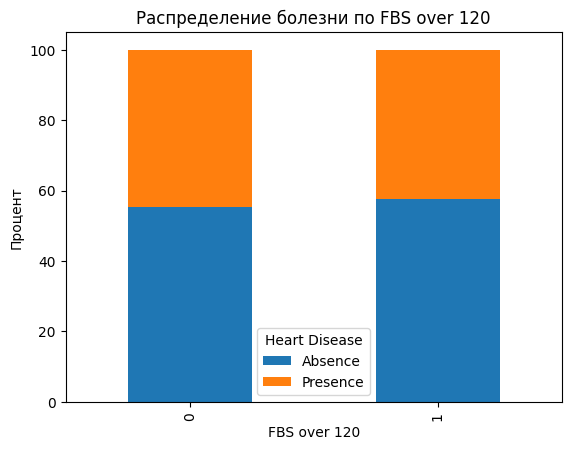

<Figure size 800x400 with 0 Axes>

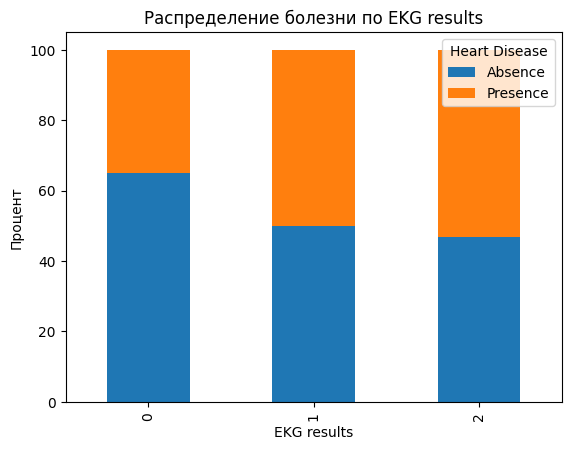

<Figure size 800x400 with 0 Axes>

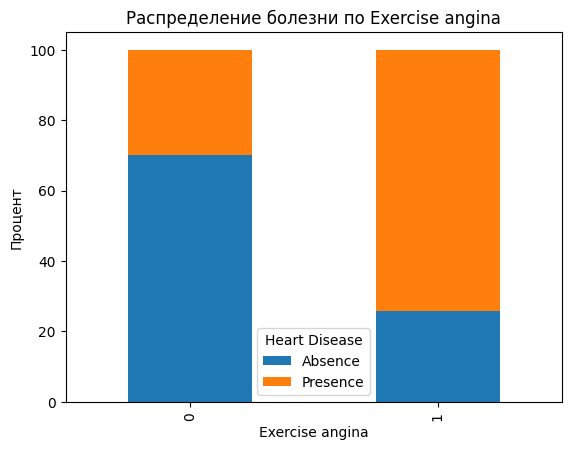

<Figure size 800x400 with 0 Axes>

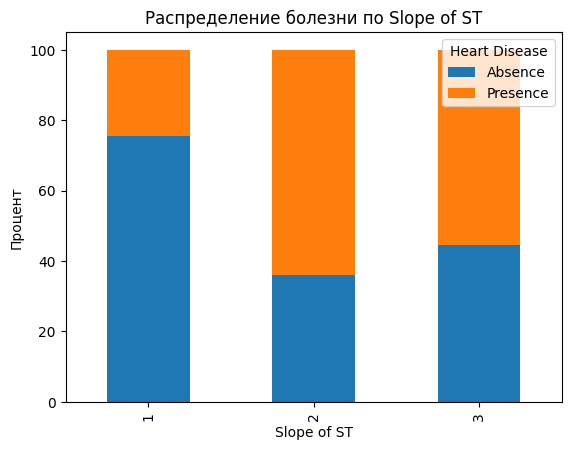

<Figure size 800x400 with 0 Axes>

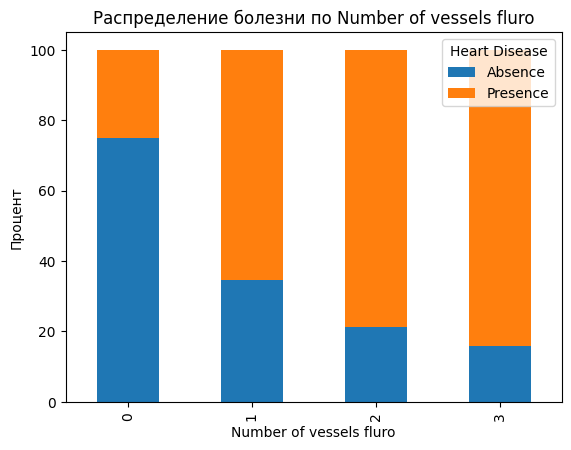

<Figure size 800x400 with 0 Axes>

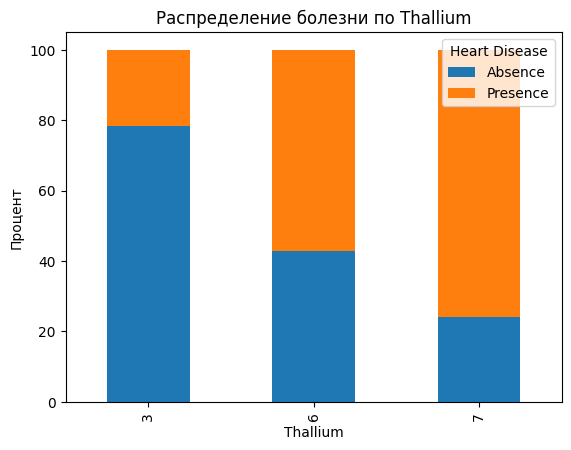

In [34]:
# Для категориальных признаков
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 
                       'EKG results', 'Exercise angina', 'Slope of ST',
                       'Number of vessels fluro', 'Thallium']

for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    cross_tab = pd.crosstab(df[feature], df['Heart Disease'], normalize='index') * 100
    
    cross_tab.plot(kind='bar', stacked=True)
    plt.title(f'Распределение болезни по {feature}')
    plt.ylabel('Процент')
    plt.xlabel(feature)
    plt.show()

In [35]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    """Вычисляет коэффициент V Крамера"""
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    
    # Корректировка для небольших таблиц
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))), p

print("=== СИЛА СВЯЗИ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ (V Крамера) ===")
for feature in ['Sex', 'Chest pain type', 'FBS over 120', 
                       'EKG results', 'Exercise angina', 'Slope of ST',
                       'Number of vessels fluro', 'Thallium']:
    contingency = pd.crosstab(df[feature], df['Heart Disease'])
    v, p = cramers_v(contingency)
    
    print(f"\n{feature}:")
    print(f"  V Крамера = {v:.3f}")
    
    # Интерпретация
    if v > 0.25:
        strength = "СИЛЬНАЯ"
    elif v > 0.15:
        strength = "УМЕРЕННАЯ"
    elif v > 0.05:
        strength = "СЛАБАЯ"
    else:
        strength = "ОЧЕНЬ СЛАБАЯ"
    
    print(f"  {strength} связь")
    print(f"  p-value = {p:.6f}")

=== СИЛА СВЯЗИ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ (V Крамера) ===

Sex:
  V Крамера = 0.284
  СИЛЬНАЯ связь
  p-value = 0.000002

Chest pain type:
  V Крамера = 0.494
  СИЛЬНАЯ связь
  p-value = 0.000000

FBS over 120:
  V Крамера = 0.000
  ОЧЕНЬ СЛАБАЯ связь
  p-value = 0.923706

EKG results:
  V Крамера = 0.161
  УМЕРЕННАЯ связь
  p-value = 0.011224

Exercise angina:
  V Крамера = 0.408
  СИЛЬНАЯ связь
  p-value = 0.000000

Slope of ST:
  V Крамера = 0.378
  СИЛЬНАЯ связь
  p-value = 0.000000

Number of vessels fluro:
  V Крамера = 0.472
  СИЛЬНАЯ связь
  p-value = 0.000000

Thallium:
  V Крамера = 0.519
  СИЛЬНАЯ связь
  p-value = 0.000000


### Сильнейшие признаки (V > 0.4):
Thallium (0.519) — тест с таллием: значения 6-7 = высокий риск

Chest pain type (0.494) — типы 1 и 4 = 70-80% вероятность болезни

Number of vessels fluro (0.472) — чем больше сосудов, тем выше риск

Exercise angina (0.408) — стенокардия при нагрузке = +20% риск

### Хорошие признаки (V 0.25-0.4):
Slope of ST (0.378) — патологический наклон ST

Sex (0.284) — мужчины болеют в 2.2 раза чаще

### Умеренные (V 0.15-0.25):
EKG results (0.161) — изменения на ЭКГ умеренно связаны

### Неинформативные:
FBS over 120 (0.000) — уровень сахара не влияет



In [68]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import pandas as pd

# Определяем признаки
numeric_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 
                       'EKG results', 'Exercise angina', 'Slope of ST',
                       'Number of vessels fluro', 'Thallium']

X = df[numeric_features + categorical_features].copy()
y = df['target']

# --- Создаем preprocessing pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         categorical_features)
    ])

# --- Применяем преобразования ---
X_processed = preprocessor.fit_transform(X)

# --- Создаем DataFrame с правильными названиями колонок ---
# Получаем названия колонок после OneHotEncoder
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Объединяем все названия колонок
feature_names = numeric_features + list(cat_feature_names)

# Создаем итоговый DataFrame
X = pd.DataFrame(X_processed, columns=feature_names)

X.head()

,Age,BP,Cholesterol,Max HR,ST depression,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3,Thallium_6,Thallium_7
0,1.712094,-0.075410,1.402212,-1.759208,1.181012,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.382140,-0.916759,6.093004,0.446409,0.481153,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.282294,-0.411950,0.219823,-0.375291,-0.656118,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.052186,-0.187590,0.258589,-1.932198,-0.743600,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2.152032,-0.636310,0.374890,-1.240239,-0.743600,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [70]:
from sklearn.linear_model import LogisticRegression

# объявим модель
model = LogisticRegression(
    penalty=None, # регуляризация (добавление штрафа за большие коэфициенты)
    random_state=42,
)

y.value_counts()

target
0    150
1    120
Name: count, dtype: int64

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
) # stratify - разделение данных с учетом распределнеия категориальной переменной

model.fit(X_train, y_train)

C:\Users\margo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [73]:
y_pred_proba = model.predict_proba(X_test)
y_pred_proba

array([[7.24253526e-02, 9.27574647e-01],
       [3.95037285e-08, 9.99999960e-01],
       [2.69225800e-01, 7.30774200e-01],
       [5.64633886e-03, 9.94353661e-01],
       [4.05843535e-02, 9.59415647e-01],
       [7.28623894e-01, 2.71376106e-01],
       [1.88244803e-03, 9.98117552e-01],
       [8.27810125e-01, 1.72189875e-01],
       [1.83113755e-01, 8.16886245e-01],
       [9.69881147e-01, 3.01188529e-02],
       [9.95521165e-01, 4.47883512e-03],
       [9.81153114e-01, 1.88468855e-02],
       [1.23332507e-01, 8.76667493e-01],
       [9.09921833e-01, 9.00781666e-02],
       [1.19235370e-01, 8.80764630e-01],
       [9.36700855e-01, 6.32991450e-02],
       [8.39572712e-08, 9.99999916e-01],
       [5.77016684e-01, 4.22983316e-01],
       [8.94426989e-01, 1.05573011e-01],
       [1.65704785e-01, 8.34295215e-01],
       [9.06845709e-01, 9.31542907e-02],
       [3.39407813e-09, 9.99999997e-01],
       [9.70469708e-01, 2.95302922e-02],
       [1.32527785e-01, 8.67472215e-01],
       [8.577042

In [74]:
for i in range(10):
  print([round(float(item), 2) for item in list(y_pred_proba[i] * 100)])

[7.24, 92.76]
[0.0, 100.0]
[26.92, 73.08]
[0.56, 99.44]
[4.06, 95.94]
[72.86, 27.14]
[0.19, 99.81]
[82.78, 17.22]
[18.31, 81.69]
[96.99, 3.01]


In [75]:
y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)

In [76]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import numpy as np

def evaluate_classification(y_true, y_pred, y_proba=None):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # ROC-AUC (если переданы вероятности)
    roc_auc = None
    if y_proba is not None:
        # Если многоклассовая классификация — One-vs-Rest
        classes = np.unique(y_true)
        y_true_onehot = np.eye(len(classes))[np.searchsorted(classes, y_true)]
        roc_auc = roc_auc_score(y_true_onehot, y_proba, multi_class='ovr')

    cm = confusion_matrix(y_true, y_pred)

    print("=== Метрики классификации ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm
    }

In [78]:
metrics = evaluate_classification(y_train, y_train_pred, y_train_proba)

=== Метрики классификации ===
Accuracy:  0.8836
Precision: 0.8835
Recall:    0.8836
F1-score:  0.8834
ROC-AUC:   0.9408

Confusion Matrix:
[[95 10]
 [12 72]]


- Accuracy: 0.884 (88.4%) Модель правильно классифицирует 88.4% пациентов
- Precision: 0.884 (88.4%) Из всех предсказанных "больных" 88.4% действительно больны
- Recall: 0.884 (88.4%) Модель находит 88.4% всех реально больных пациентов
- F1-score: 0.883 Гармоническое среднее Precision и Recall
- ROC-AUC: 0.941 Модель очень хорошо разделяет классы

Ошибки модели:

10 здоровых пациентов ошибочно назвали больными 

12 больных пациентов пропустили

In [79]:
metrics = evaluate_classification(y_test, y_pred, y_proba)

=== Метрики классификации ===
Accuracy:  0.8642
Precision: 0.8777
Recall:    0.8642
F1-score:  0.8645
ROC-AUC:   0.8932

Confusion Matrix:
[[36  9]
 [ 2 34]]


### Нет переобучения

Train accuracy (0.884) vs Test accuracy (0.864) — разница всего 2%

Train AUC (0.941) vs Test AUC (0.893) — разница 4.8% (немного хуже разделяет классы)

Модель обобщает хорошо — **нет сильного переобучения**

### Анализ ошибок улучшился
На тесте:

Ложно больные: 9 (было 10 на трейне)

Ложно здоровые: 2 (было 12 на трейне)

### Вывод

- Высокая точность (86.4%) на новых данных

- Низкий процент пропущенных больных (всего 2 человека!)

- Нет переобучения — модель обобщает хорошо

- ROC-AUC 0.893 — хорошее разделение классов

## Улучшение модели

In [80]:
from sklearn.ensemble import RandomForestClassifier

# Улучшенная модель
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Оценка
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

print("=== RANDOM FOREST (улучшенная модель) ===")
evaluate_classification(y_test, y_pred_rf, y_proba_rf)

# Сравнение с baseline
print("\n=== СРАВНЕНИЕ С BASELINE ===")
print(f"LogisticRegression Accuracy: {0.8642:.3f}")
print(f"RandomForest Accuracy:      {accuracy_score(y_test, y_pred_rf):.3f}")

=== RANDOM FOREST (улучшенная модель) ===
=== Метрики классификации ===
Accuracy:  0.8765
Precision: 0.8816
Recall:    0.8765
F1-score:  0.8769
ROC-AUC:   0.9253

Confusion Matrix:
[[38  7]
 [ 3 33]]

=== СРАВНЕНИЕ С BASELINE ===
LogisticRegression Accuracy: 0.864
RandomForest Accuracy:      0.877


### Что стало лучше:
- Accuracy: +1.3% (0.864 → 0.877)

- ROC-AUC: +3.2% (0.893 → 0.925) — значимое улучшение!

- False Positives: -2 (9 → 7) — меньше ложных диагнозов!

### Что немного ухудшилось:
- False Negatives: +1 (2 → 3) — на одного больше пропущенных больных

## Вывод
#### Logistic Regression (Baseline):

- Accuracy: 86.4%

- ROC-AUC:   0.8932

- Пропущено больных: 2

- Ложных диагнозов: 9

#### Random Forest (Улучшенная):

- Accuracy: 87.7% (+1.3%)

- ROC-AUC: 0.925 (отличный результат)

- Ложных диагнозов: 7 (-22%)

- Пропущено больных: 3 (+1)"

#### Рекомендация:
Random Forest показывает лучшие общие метрики

Logistic Regression лучше находит реально больных

Выбор модели зависит от приоритетов: точность или безопасность